# EMB-CAR Employee ID Card Generator

Google Sheets/Drive -> data cleaning -> photo & signature processing -> card compositing -> print-ready PDF.

Run cells top to bottom on first use. Re-running later only processes new form submissions.

**This revision adds:** guards against a 0-response sheet, retry-with-backoff for transient Google API errors (503/500/429/timeouts), real measured template coordinates, Montserrat fonts, full-width barcode, and timestamped output filenames under `output/cards/printables/`.

## Stage 1: Imports

In [1]:
import pandas as pd
import numpy as np
from PIL import Image, ImageDraw, ImageFont
from pathlib import Path
import re
import json
import math
import time
import random
import urllib.request
from io import BytesIO
from datetime import datetime
from concurrent.futures import ThreadPoolExecutor, as_completed

import cv2
from rembg import remove
import barcode
from barcode.writer import ImageWriter
import qrcode
import img2pdf
import requests

import gspread
from google.oauth2.service_account import Credentials
from google.auth.transport.requests import AuthorizedSession

import matplotlib.pyplot as plt

print("All imports successful")

All imports successful


## Stage 1b: Project paths

In [2]:
BASE_DIR = Path.cwd()
TEMPLATE_DIR = BASE_DIR / "templates"
DATA_DIR = BASE_DIR / "data"
PHOTOS_DIR = BASE_DIR / "photos"
SIGNATURES_DIR = BASE_DIR / "signatures"

OUTPUT_DIR = BASE_DIR / "output"
OUTPUT_CARDS_DIR = OUTPUT_DIR / "cards"
OUTPUT_PRINTABLES_DIR = OUTPUT_DIR / "printables"
OUTPUT_FORMS_DIR = OUTPUT_DIR / "forms"

FONT_DIR = BASE_DIR / "fonts"
MODELS_DIR = BASE_DIR / "models"
CREDS_PATH = BASE_DIR / "credentials" / "service_account.json"
LAST_RUN_FILE = DATA_DIR / "last_run.json"

RESOURCE_DIRS = [
    DATA_DIR, 
    PHOTOS_DIR, 
    SIGNATURES_DIR, 
    OUTPUT_DIR, 
    OUTPUT_CARDS_DIR, 
    OUTPUT_PRINTABLES_DIR, 
    OUTPUT_FORMS_DIR, 
    MODELS_DIR
]

for d in RESOURCE_DIRS:
    already_existed = d.exists()
    d.mkdir(parents=True, exist_ok=True)
    print(f"{d} {'already existed' if already_existed else 'was missing -- created it'}")

MAX_WORKERS = 8

front_template = Image.open(TEMPLATE_DIR / "front_template.png")
back_template = Image.open(TEMPLATE_DIR / "back_template.png")
form_template = Image.open(TEMPLATE_DIR / "request_form.jpg")

print("Front template size:", front_template.size)
print("Back template size:", back_template.size)
print("Form template size:", form_template.size)

c:\Users\USER\Documents\System Project\id-card-generator\data already existed
c:\Users\USER\Documents\System Project\id-card-generator\photos already existed
c:\Users\USER\Documents\System Project\id-card-generator\signatures already existed
c:\Users\USER\Documents\System Project\id-card-generator\output already existed
c:\Users\USER\Documents\System Project\id-card-generator\output\cards already existed
c:\Users\USER\Documents\System Project\id-card-generator\output\printables already existed
c:\Users\USER\Documents\System Project\id-card-generator\output\forms already existed
c:\Users\USER\Documents\System Project\id-card-generator\models already existed
Front template size: (643, 1015)
Back template size: (643, 1015)
Form template size: (2550, 3900)


In [3]:
CASCADE_PATH = MODELS_DIR / "haarcascade_frontalface_default.xml"

if not CASCADE_PATH.exists():
    url = "https://raw.githubusercontent.com/opencv/opencv/4.x/data/haarcascades/haarcascade_frontalface_default.xml"
    urllib.request.urlretrieve(url, CASCADE_PATH)
    print("Downloaded cascade file")

_haar_cascade = cv2.CascadeClassifier(str(CASCADE_PATH))
print("Classifier loaded successfully:", not _haar_cascade.empty())

Classifier loaded successfully: True


## Stage 1c: Retry helper (for transient Google API errors) + font helpers

In [4]:
def retry_with_backoff(func, max_retries=5, base_delay=1.5, retryable_statuses=(429, 500, 502, 503, 504)):
    """Calls func() with exponential backoff on transient errors (5xx, 429, timeouts, connection errors).
    Raises immediately on non-retryable errors (403 permission denied, 404 not found, etc.) --
    those will never succeed no matter how many times we retry."""
    for attempt in range(max_retries):
        try:
            return func()
        except Exception as e:
            status = getattr(getattr(e, "response", None), "status_code", None)
            is_transient = status in retryable_statuses or isinstance(
                e, (requests.exceptions.ConnectionError, requests.exceptions.Timeout)
            )
            if not is_transient or attempt == max_retries - 1:
                raise
            delay = base_delay * (2 ** attempt) + random.uniform(0, 1)
            print(f"Transient error ({e}) -- retrying in {delay:.1f}s (attempt {attempt + 1}/{max_retries})")
            time.sleep(delay)

In [5]:
def font_bold(size):
    return ImageFont.truetype(str(FONT_DIR / "Montserrat-Black.ttf"), size)

def font_regular(size):
    return ImageFont.truetype(str(FONT_DIR / "Montserrat-SemiBold.ttf"), size)

def font_semibold(size):
    return ImageFont.truetype(str(FONT_DIR / "Montserrat-Bold.ttf"), size)

## Stage 2: Connect to Google Sheets and Drive

One service account credential for both. Make sure the Sheet and the Drive folder are shared with the service account's email.

Guarded against: a 0-response sheet (would otherwise cause `KeyError` on every later column reference), and transient API errors (via `retry_with_backoff`).

In [6]:
SCOPES = [
    "https://www.googleapis.com/auth/spreadsheets.readonly",
    "https://www.googleapis.com/auth/drive.readonly",
]

creds = Credentials.from_service_account_file(CREDS_PATH, scopes=SCOPES)
gc = gspread.authorize(creds)
authed_session = AuthorizedSession(creds)

SHEET_URL = "https://docs.google.com/spreadsheets/d/1_GKJPfENYbBNBoz11J-eYmQquKm1TTCxu63ChhnLwDM/edit"

EXPECTED_RAW_COLUMNS = [
    "Timestamp", "ID NUMBER", "FULL NAME", "POSITION", "HOME ADDRESS",
    "TIN NUMBER (if any)", "GSIS NUMBER (if any)", "BLOOD TYPE",
    "EMERGENCY CONTACT PERSON", "EMERGENCY CONTACT NUMBER",
    "E-SIGNATURE", "ID PICTURE", "EMPLOYEE TYPE",
    "EXPECTED DATE OF COMPLETION",
]

sheet = retry_with_backoff(lambda: gc.open_by_url(SHEET_URL).sheet1)
records = retry_with_backoff(lambda: sheet.get_all_records())

if len(records) == 0:
    print("WARNING: 0 responses in the sheet. Continuing with an empty dataset -- later stages will safely process nothing.")
    df = pd.DataFrame(columns=EXPECTED_RAW_COLUMNS)
else:
    df = pd.DataFrame(records)

print(f"Loaded {len(df)} responses")
df.head()

Loaded 2 responses


,Timestamp,ID NUMBER,FULL NAME,POSITION,HOME ADDRESS,TIN NUMBER (if any),GSIS NUMBER (if any),BLOOD TYPE,EMERGENCY CONTACT PERSON,EMERGENCY CONTACT NUMBER,E-SIGNATURE,ID PICTURE,EMPLOYEE TYPE,Email Address,EXPECTED DATE OF COMPLETION
0,8/24/2026 16:25:48,EMBB-O29-73-2024,Melodie S. Sacla,Information Officer Staff,"Tawang, La Trinidad, Benguet",N/A,N/A,O-,Michelle S. Lambac,0950-301-2280,https://drive.google.com/open?id=1n0m3x8Ra0YLa...,https://drive.google.com/open?id=1JQ0c8luCTPfS...,Permanent,,
1,9/9/2026 9:43:21,EMBB-27-2026,JOHN DOE,ON-THE-JOB TRAINEE,"GIBRALTAR, BAGUIO CITY",,,UNKNOWN / NOT SURE,MARY JANE,9208775467,https://drive.google.com/open?id=1kALh2TfC-_Yi...,https://drive.google.com/open?id=1o9EPcLIUtsum...,OJT,vincentbolinget@gmail.com,10/31/2026


## Stage 2c: Rename columns to code-friendly names

In [7]:
df = df.rename(columns={
    "Timestamp": "date_submitted",
    "ID NUMBER": "id_number",
    "FULL NAME": "full_name",
    "EXPECTED DATE OF COMPLETION" : "valid_until",
    "POSITION": "position",
    "HOME ADDRESS": "address",
    "TIN NUMBER (if any)": "tin",
    "GSIS NUMBER (if any)": "gsis",
    "BLOOD TYPE": "blood_type",
    "EMERGENCY CONTACT PERSON": "emergency_contact_person",
    "EMERGENCY CONTACT NUMBER": "emergency_contact_number",
    "E-SIGNATURE": "e_signature_path",
    "ID PICTURE": "id_picture_path",
    "EMPLOYEE TYPE": "employee_type",
})
df.head()

,date_submitted,id_number,full_name,position,address,tin,gsis,blood_type,emergency_contact_person,emergency_contact_number,e_signature_path,id_picture_path,employee_type,Email Address,valid_until
0,8/24/2026 16:25:48,EMBB-O29-73-2024,Melodie S. Sacla,Information Officer Staff,"Tawang, La Trinidad, Benguet",N/A,N/A,O-,Michelle S. Lambac,0950-301-2280,https://drive.google.com/open?id=1n0m3x8Ra0YLa...,https://drive.google.com/open?id=1JQ0c8luCTPfS...,Permanent,,
1,9/9/2026 9:43:21,EMBB-27-2026,JOHN DOE,ON-THE-JOB TRAINEE,"GIBRALTAR, BAGUIO CITY",,,UNKNOWN / NOT SURE,MARY JANE,9208775467,https://drive.google.com/open?id=1kALh2TfC-_Yi...,https://drive.google.com/open?id=1o9EPcLIUtsum...,OJT,vincentbolinget@gmail.com,10/31/2026


## Stage 2d: Clean and validate

- Missing ID numbers get a visible placeholder (never a blank field)
- Blank cells become "N/A"
- Every text field is uppercased EXCEPT the Drive link columns (case-sensitive URLs)

All of this safely no-ops on a 0-row DataFrame -- no special-casing needed here since Stage 2 already guaranteed the right columns exist.

In [8]:
def clean_numeric_id(raw) -> str | None:
    """Shared first step: handles NaN/None/int/float safely, strips non-digits.
    Returns None if there's genuinely nothing usable."""
    if raw is None or (isinstance(raw, float) and pd.isna(raw)):
        return None
    raw_str = str(raw).strip()
    if raw_str == "" or raw_str.upper() in ("N/A", "NAN"):
        return None
    return re.sub(r"\D", "", raw_str)


def normalize_tin(raw) -> tuple[str, str]:
    """BIR standard: 9 digits (individuals) as XXX-XXX-XXX,
    or 12 digits (with branch code) as XXX-XXX-XXX-XXXX."""
    digits = clean_numeric_id(raw)
    if digits is None:
        return "N/A", "not_provided"

    if len(digits) == 9:
        return f"{digits[0:3]}-{digits[3:6]}-{digits[6:9]}", "tin_individual"
    if len(digits) == 12:
        return f"{digits[0:3]}-{digits[3:6]}-{digits[6:9]}-{digits[9:12]}", "tin_branch"

    return digits, "unrecognized"


def normalize_gsis(raw) -> tuple[str, str]:
    """GSIS BP numbers don't have one official universal format the way TIN
    does -- length varies 9-11 digits depending on issue date. This groups
    for readability; adjust the grouping if your office follows a specific
    house-style format instead."""
    digits = clean_numeric_id(raw)
    if digits is None:
        return "N/A", "not_provided"

    if len(digits) == 11:
        return f"{digits[0:2]}-{digits[2:9]}-{digits[9:11]}", "gsis_11"
    if len(digits) == 9:
        return f"{digits[0:3]}-{digits[3:6]}-{digits[6:9]}", "gsis_9"
    if len(digits) == 10:
        return f"{digits[0:2]}-{digits[2:8]}-{digits[8:10]}", "gsis_10"

    return digits, "unrecognized"

def format_tin(raw):
    formatted, kind = normalize_tin(raw)
    if kind == "unrecognized":
        print(f"WARNING: unrecognized TIN format: {raw!r} -> left as {formatted}")
    return formatted

def format_gsis(raw):
    formatted, kind = normalize_gsis(raw)
    if kind == "unrecognized":
        print(f"WARNING: unrecognized GSIS format: {raw!r} -> left as {formatted}")
    return formatted

In [9]:
def normalize_phone(raw) -> tuple[str, str]:
    # Handle real missing values (NaN, None) before converting to string --
    # str(NaN) becomes the literal text "nan", which we don't want to treat as a valid number
    if raw is None or (isinstance(raw, float) and pd.isna(raw)):
        return "N/A", "empty"

    raw_str = str(raw).strip()
    if raw_str == "" or raw_str.upper() in ("N/A", "NAN"):
        return "N/A", "not_provided"

    digits = re.sub(r"\D", "", raw_str)

    if digits.startswith("63") and len(digits) == 12:
        digits = "0" + digits[2:]
    elif digits.startswith("9") and len(digits) == 10:
        digits = "0" + digits

    if digits.startswith("09") and len(digits) == 11:
        return f"{digits[0:4]} {digits[4:7]} {digits[7:11]}", "mobile"

    if 9 <= len(digits) <= 10 and not digits.startswith("09"):
        area_code, local = digits[:-7], digits[-7:]
        return f"({area_code}) {local[:3]} {local[3:]}", "landline"

    if len(digits) == 7:
        return f"{digits[:3]} {digits[3:]}", "landline_no_area_code"

    return digits if digits else raw_str, "unrecognized"
    

def format_contact_number(raw):
    formatted, kind = normalize_phone(raw)
    if kind == "unrecognized":
        print(f"WARNING: could not confidently format phone number: {raw!r} -> left as is")
    return formatted

In [10]:
PLACEHOLDER_ID = "EMBB-000-0000"

df["id_number"] = df["id_number"].astype(str).str.strip()
df["id_number"] = df["id_number"].replace(["", "nan", "None"], PLACEHOLDER_ID)
df["id_missing"] = df["id_number"] == PLACEHOLDER_ID

df["emergency_contact_number"] = df["emergency_contact_number"].apply(format_contact_number)

df["tin"] = df["tin"].apply(format_tin)
df["gsis"] = df["gsis"].apply(format_gsis)

if df["id_missing"].sum() > 0:
    print(f"WARNING: {df['id_missing'].sum()} row(s) using placeholder ID -- review before printing:")
    print(df.loc[df["id_missing"], ["full_name", "position"]])

df = df.fillna("N/A")
df = df.replace(r'^\s*$', "N/A", regex=True)

exclude_cols = ["e_signature_path", "id_picture_path"]
missing_exclude_cols = [c for c in exclude_cols if c not in df.columns]
if missing_exclude_cols:
    print(f"WARNING: exclude columns not found in df: {missing_exclude_cols}")

cols_to_upper = [col for col in df.columns if col not in exclude_cols]
for col in cols_to_upper:
    df[col] = df[col].apply(lambda x: x.upper() if isinstance(x, str) else x)

df

,date_submitted,id_number,full_name,position,address,tin,gsis,blood_type,emergency_contact_person,emergency_contact_number,e_signature_path,id_picture_path,employee_type,Email Address,valid_until,id_missing
0,8/24/2026 16:25:48,EMBB-O29-73-2024,MELODIE S. SACLA,INFORMATION OFFICER STAFF,"TAWANG, LA TRINIDAD, BENGUET",N/A,N/A,O-,MICHELLE S. LAMBAC,0950 301 2280,https://drive.google.com/open?id=1n0m3x8Ra0YLa...,https://drive.google.com/open?id=1JQ0c8luCTPfS...,PERMANENT,N/A,N/A,False
1,9/9/2026 9:43:21,EMBB-27-2026,JOHN DOE,ON-THE-JOB TRAINEE,"GIBRALTAR, BAGUIO CITY",N/A,N/A,UNKNOWN / NOT SURE,MARY JANE,0920 877 5467,https://drive.google.com/open?id=1kALh2TfC-_Yi...,https://drive.google.com/open?id=1o9EPcLIUtsum...,OJT,VINCENTBOLINGET@GMAIL.COM,10/31/2026,False


## Stage 3: Drive fetching + image processing helpers

In [11]:
def extract_drive_file_id(url) -> str | None:
    """Pulls the file ID out of a Google Drive share link, handling the
    common URL formats Drive/Forms generates."""
    if not isinstance(url, str) or not url.strip():
        return None
    match = re.search(r'/d/([-\w]{25,})', url)
    if match:
        return match.group(1)
    match = re.search(r'[?&]id=([-\w]{25,})', url)
    if match:
        return match.group(1)
    match = re.search(r'[-\w]{25,}', url)
    return match.group(0) if match else None


def download_drive_image(file_id: str) -> Image.Image:
    """Fetches a file from Drive with a timeout + retry -- without the timeout,
    a hung connection would block forever and never trigger the retry logic."""
    def _do_request():
        url = f"https://www.googleapis.com/drive/v3/files/{file_id}?alt=media"
        response = authed_session.get(url, timeout=30)
        response.raise_for_status()
        return response

    response = retry_with_backoff(_do_request)
    return Image.open(BytesIO(response.content)).convert("RGB")

In [12]:
def is_background_white(img: Image.Image, tolerance=25, border_pct=0.05):
    """Sample a thin border strip around the photo and check how close
    the average color is to pure white."""
    img_rgb = img.convert("RGB")
    w, h = img_rgb.size
    arr = np.array(img_rgb)
    bw, bh = max(1, int(w * border_pct)), max(1, int(h * border_pct))
    border_pixels = np.concatenate([
        arr[:bh, :].reshape(-1, 3),
        arr[-bh:, :].reshape(-1, 3),
        arr[:, :bw].reshape(-1, 3),
        arr[:, -bw:].reshape(-1, 3),
    ])
    avg_color = border_pixels.mean(axis=0)
    distance_from_white = np.linalg.norm(np.array([255, 255, 255]) - avg_color)
    return distance_from_white < tolerance


def remove_and_whiten_background(img: Image.Image, max_dim: int = 1024) -> Image.Image:
    """Cut the person out via rembg, then composite onto a solid white canvas.
    Downscales before running the model to avoid memory issues on large images."""
    original_size = img.size
    w, h = original_size
    scale = min(1.0, max_dim / max(w, h))
    small_img = img.resize((int(w * scale), int(h * scale)), Image.LANCZOS) if scale < 1.0 else img
    small_rgba = remove(small_img.convert("RGBA"))
    img_rgba = small_rgba.resize(original_size, Image.LANCZOS) if scale < 1.0 else small_rgba
    white_bg = Image.new("RGBA", original_size, (255, 255, 255, 255))
    composited = Image.alpha_composite(white_bg, img_rgba)
    return composited.convert("RGB")

In [13]:
YUNET_MODEL_PATH = MODELS_DIR / "face_detection_yunet_2023mar.onnx"
CASCADE_PATH = MODELS_DIR / "haarcascade_frontalface_default.xml"

# Auto-download the Haar cascade if it's missing or corrupted -- this is what
# was silently breaking after every kernel restart before
if not CASCADE_PATH.exists() or CASCADE_PATH.stat().st_size < 100_000:
    print("Downloading Haar cascade model...")
    url = "https://raw.githubusercontent.com/opencv/opencv/4.x/data/haarcascades/haarcascade_frontalface_default.xml"
    urllib.request.urlretrieve(url, CASCADE_PATH)

_haar_cascade = cv2.CascadeClassifier(str(CASCADE_PATH))
if _haar_cascade.empty():
    raise RuntimeError(
        f"Haar cascade failed to load from {CASCADE_PATH}. "
        f"Exists: {CASCADE_PATH.exists()}, size: {CASCADE_PATH.stat().st_size if CASCADE_PATH.exists() else 0} bytes."
    )
print("Haar cascade loaded successfully.")


def detect_face_box(img: Image.Image):
    arr = np.array(img.convert("RGB"))
    h, w = arr.shape[:2]

    if YUNET_MODEL_PATH.exists():
        detector = cv2.FaceDetectorYN.create(str(YUNET_MODEL_PATH), "", (w, h), score_threshold=0.5)
        _, faces = detector.detect(arr)
        if faces is None or len(faces) == 0:
            return None
        best = max(faces, key=lambda f: f[-1])
        x, y, bw, bh = best[:4].astype(int)
        return (x, y, x + bw, y + bh)
    else:
        gray = np.array(img.convert("L"))
        detected = _haar_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5, minSize=(60, 60))
        if len(detected) == 0:
            return None
        x, y, bw, bh = max(detected, key=lambda f: f[2] * f[3])
        return (x, y, x + bw, y + bh)


def recrop_on_face(img: Image.Image, face_box, target_aspect=190/250):
    """Recenter/recrop so the face follows standard ID-photo composition."""
    w, h = img.size
    x_min, y_min, x_max, y_max = face_box
    face_h = y_max - y_min
    face_cx, face_cy = (x_min + x_max) / 2, (y_min + y_max) / 2
    target_h = face_h / 0.5
    target_w = target_h * target_aspect
    crop_top = face_cy - target_h * 0.42
    crop_left = face_cx - target_w / 2
    crop_box = (int(crop_left), int(crop_top), int(crop_left + target_w), int(crop_top + target_h))
    canvas = Image.new("RGB", (crop_box[2] - crop_box[0], crop_box[3] - crop_box[1]), (255, 255, 255))
    src_box = (max(0, crop_box[0]), max(0, crop_box[1]), min(w, crop_box[2]), min(h, crop_box[3]))
    paste_pos = (max(0, -crop_box[0]), max(0, -crop_box[1]))
    canvas.paste(img.crop(src_box), paste_pos)
    return canvas


def process_id_photo_from_image(img: Image.Image):
    flags = {"bg_fixed": False, "needs_review": False, "face_detected": False, "cached": False}
    if not is_background_white(img):
        img = remove_and_whiten_background(img)
        flags["bg_fixed"] = True
    face_box = detect_face_box(img)
    if face_box is None:
        flags["needs_review"] = True
    else:
        flags["face_detected"] = True
        w, _ = img.size
        face_cx = (face_box[0] + face_box[2]) / 2
        offset_pct = abs(face_cx - w / 2) / w
        if offset_pct > 0.08:
            img = recrop_on_face(img, face_box)
            flags["needs_review"] = True
    return img, flags

Haar cascade loaded successfully.


In [14]:
def process_signature_image(img: Image.Image, threshold=200) -> Image.Image:
    """Converts a signature photo/scan into a transparent PNG -- light paper
    becomes transparent, dark ink stays opaque black. Cropped tight to the ink."""
    gray = img.convert("L")
    arr = np.array(gray)
    alpha = np.where(arr < threshold, 255, 0).astype(np.uint8)
    black_layer = Image.new("RGBA", img.size, (20, 20, 20, 255))
    transparent_layer = Image.new("RGBA", img.size, (0, 0, 0, 0))
    signature_rgba = Image.composite(black_layer, transparent_layer, Image.fromarray(alpha))
    bbox = signature_rgba.getbbox()
    if bbox:
        signature_rgba = signature_rgba.crop(bbox)
    return signature_rgba

In [15]:
def process_row(row):
    """Fetches + processes both the ID photo and e-signature for one row.
    Returns a dict so every outcome (success, cached, or a specific error) is explicit."""
    id_num = row["id_number"]
    photo_cache = PHOTOS_DIR / f"{id_num}.png"
    sig_cache = SIGNATURES_DIR / f"{id_num}.png"

    result = {"id_number": id_num, "photo": None, "photo_flags": {}, "signature": None, "signature_error": None}

    if photo_cache.exists():
        result["photo"] = Image.open(photo_cache)
        result["photo_flags"] = {"cached": True}
    else:
        file_id = extract_drive_file_id(row["id_picture_path"])
        if not file_id:
            result["photo_flags"] = {"error": "no valid photo URL/file ID"}
        else:
            try:
                raw_img = download_drive_image(file_id)
                processed_img, flags = process_id_photo_from_image(raw_img)
                processed_img.save(photo_cache)
                result["photo"] = processed_img
                result["photo_flags"] = flags
            except Exception as e:
                result["photo_flags"] = {"error": str(e)}

    if sig_cache.exists():
        result["signature"] = Image.open(sig_cache)
    else:
        sig_file_id = extract_drive_file_id(row["e_signature_path"])
        if not sig_file_id:
            result["signature_error"] = "no valid signature URL/file ID"
        else:
            try:
                raw_sig = download_drive_image(sig_file_id)
                processed_sig = process_signature_image(raw_sig)
                processed_sig.save(sig_cache)
                result["signature"] = processed_sig
            except Exception as e:
                result["signature_error"] = str(e)

    return result

## Stage 3b: Fetch + process every photo/signature

Only processes rows submitted since the last successful run. Runs concurrently. Safely does nothing if `df` is empty. Set `FORCE_FULL_REPROCESS = True` to bypass the filter and redo everyone.

In [16]:
FORCE_FULL_REPROCESS = False

all_results = {}

if len(df) == 0:
    print("No responses to process.")
    df_to_process = df.copy()
else:
    df["date_submitted"] = pd.to_datetime(df["date_submitted"])

    if LAST_RUN_FILE.exists() and not FORCE_FULL_REPROCESS:
        with open(LAST_RUN_FILE) as f:
            last_ts = pd.to_datetime(json.load(f)["last_processed_timestamp"])
        df_to_process = df[df["date_submitted"] > last_ts].copy()
        print(f"Last run: {last_ts} -- processing {len(df_to_process)} new submission(s)")
    else:
        df_to_process = df.copy()
        print(f"Processing all {len(df_to_process)} row(s)")

    with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
        futures = {executor.submit(process_row, row): row["id_number"] for _, row in df_to_process.iterrows()}
        for future in as_completed(futures):
            result = future.result()
            all_results[result["id_number"]] = result
            print(f"{result['id_number']}: photo={result['photo_flags']}, sig_error={result['signature_error']}")

    if len(df_to_process) > 0:
        with open(LAST_RUN_FILE, "w") as f:
            json.dump({"last_processed_timestamp": df_to_process["date_submitted"].max().isoformat()}, f)

print(f"\nDone. Processed {len(all_results)} row(s) this run.")

Processing all 2 row(s)
Transient error (HTTPSConnectionPool(host='www.googleapis.com', port=443): Read timed out. (read timeout=30)) -- retrying in 2.3s (attempt 1/5)
EMBB-O29-73-2024: photo={'bg_fixed': False, 'needs_review': False, 'face_detected': True, 'cached': False}, sig_error=None
EMBB-27-2026: photo={'bg_fixed': True, 'needs_review': False, 'face_detected': True, 'cached': False}, sig_error=None

Done. Processed 2 row(s) this run.


## Stage 3c: Review anything flagged

In [17]:
def show_grid(images_with_titles, cols=4):
    if not images_with_titles:
        print("Nothing to show.")
        return
    rows = (len(images_with_titles) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 3))
    axes = axes.flatten() if rows * cols > 1 else [axes]
    for ax, (img, title) in zip(axes, images_with_titles):
        if img is not None:
            ax.imshow(img)
        ax.set_title(title, fontsize=8)
        ax.axis("off")
    for ax in axes[len(images_with_titles):]:
        ax.axis("off")
    plt.tight_layout()
    plt.show()


flagged = {
    id_num: r for id_num, r in all_results.items()
    if r["photo_flags"].get("error") or r["photo_flags"].get("needs_review") or r["signature_error"]
}
print(f"{len(flagged)} row(s) flagged for review out of {len(all_results)}")
if flagged:
    show_grid([(r["photo"], f"{id_num}\n{r['photo_flags']}") for id_num, r in flagged.items()])
else:
    print("Nothing flagged.")

0 row(s) flagged for review out of 2
Nothing flagged.


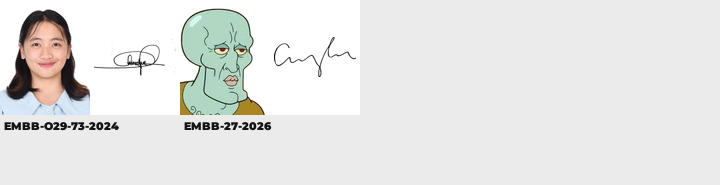

In [18]:
def cover_resize(img: Image.Image, target_w: int, target_h: int) -> Image.Image:
    """Resize to completely fill (target_w, target_h), cropping any overflow --
    every output is exactly the same size regardless of source aspect ratio."""
    img = img.convert("RGB")
    src_w, src_h = img.size
    scale = max(target_w / src_w, target_h / src_h)
    new_w, new_h = int(src_w * scale), int(src_h * scale)
    resized = img.resize((new_w, new_h), Image.LANCZOS)
    left, top = (new_w - target_w) // 2, (new_h - target_h) // 2
    return resized.crop((left, top, left + target_w, top + target_h))

def fit_resize(img, max_w, max_h):
    """Unlike .thumbnail(), this allows enlarging too -- scales proportionally
    to fit within (max_w, max_h), upscale or downscale as needed."""
    src_w, src_h = img.size
    scale = min(max_w / src_w, max_h / src_h)
    new_w, new_h = max(1, int(src_w * scale)), max(1, int(src_h * scale))
    return img.resize((new_w, new_h), Image.LANCZOS)

def build_preview_sheet(all_results, photo_w=90, photo_h=115, sig_w=90, sig_h=115, label_font_size=11):
    ids = list(all_results.keys())
    cols = 4
    thumb_size = photo_w + sig_w
    rows = math.ceil(len(ids) / cols) if ids else 1
    cell_h = photo_h + 70
    sheet = Image.new("RGB", (cols * thumb_size, rows * cell_h), (235, 235, 235))
    draw = ImageDraw.Draw(sheet)
    label_font = font_bold(label_font_size)
    small_font = font_regular(label_font_size - 1)

    for i, id_num in enumerate(ids):
        result = all_results[id_num]
        col, row = i % cols, i // cols
        x, y = col * thumb_size, row * cell_h

        photo = result.get("photo")
        if photo:
            sheet.paste(cover_resize(photo, photo_w, photo_h), (x, y))
        else:
            draw.rectangle([x, y, x + photo_w, y + photo_h], outline=(200, 0, 0), width=2)
            draw.text((x + 6, y + photo_h // 2), "NO PHOTO", font=small_font, fill=(200, 0, 0))

        sig = result.get("signature")
        sig_bg = Image.new("RGB", (sig_w, sig_h), (255, 255, 255))
        if sig:
            sig_thumb = sig.copy()
            sig_thumb.thumbnail((sig_w - 8, sig_h - 8))
            paste_x, paste_y = (sig_w - sig_thumb.width) // 2, (sig_h - sig_thumb.height) // 2
            sig_bg.paste(sig_thumb, (paste_x, paste_y), sig_thumb if sig_thumb.mode == "RGBA" else None)
        else:
            d2 = ImageDraw.Draw(sig_bg)
            d2.rectangle([0, 0, sig_w - 1, sig_h - 1], outline=(200, 0, 0), width=2)
            d2.text((6, sig_h // 2), "NO SIG", font=small_font, fill=(200, 0, 0))
        sheet.paste(sig_bg, (x + photo_w, y))

        draw.text((x + 4, y + photo_h + 4), id_num, font=label_font, fill=(20, 20, 20))
        status_lines = []
        if result["photo_flags"].get("needs_review"):
            status_lines.append("photo: REVIEW")
        if result["photo_flags"].get("error"):
            status_lines.append(f"photo err: {result['photo_flags']['error'][:20]}")
        if result["signature_error"]:
            status_lines.append(f"sig err: {result['signature_error'][:20]}")
        sy = y + photo_h + 22
        for line in status_lines:
            draw.text((x + 4, sy), line, font=small_font, fill=(180, 0, 0))
            sy += 14

    return sheet

if all_results:
    preview = build_preview_sheet(all_results)
    display(preview)
else:
    print("Nothing to preview yet.")

## Stage 4: Placing photos, text, barcode, and QR onto the templates

Labels ("ADDRESS:", "GSIS:", "TIN NUMBER:", etc.) are already baked into the template artwork -- these functions only draw the *values*.

In [19]:
# Measured directly from the final template files (pixel color-boundary detection).
FRONT_LAYOUT = {
    "photo_box": (110, 168, 535, 619),       # measured: navy border edges
    "full_name": (330, 660),                  # centered -- see anchor note below
    "position": (330, 733),                   # centered, inside the navy band
    "id_number": (305, 930),                  # centered, above the barcode
    "barcode_box": (40, 938, 600, 980),
}

BACK_LAYOUT = {
    # Labels are already printed on the template -- these are VALUE positions only
    "address": (64, 100),          # multi-line -- wraps automatically, see build_back_card
    "gsis": (337, 100),
    "tin": (64, 170),
    "blood_type": (337, 170),
    "date_field": (64, 220),
    "emergency_contact_person": (64, 383),
    "emergency_contact_number": (334, 383),
    "signature_box": (150, 815, 495, 925),
}

REQUEST_FORM_LAYOUT = {
    "date": (2160, 525),
    "name": (940, 720),
    "position": (940, 820),
    "address": (940, 920),
    "tin": (940, 1080),
    "gsis": (940, 1170),
    "blood_type": (940, 1260),
    "emergency_contact": (940, 1390),   # person + number combined, matches the form's single cell
    "signature_box": (925, 1585, 2355, 1870),
    "photo_2x2_box": (940, 1910, 1539, 2500),
    "photo_1x1_box": (1660, 2070, 1955, 2373),
}

In [20]:
def make_coordinate_grid(template_path, major_spacing=50, minor_spacing=10, crop_box=None):
    img = Image.open(template_path).convert("RGB")
    draw = ImageDraw.Draw(img)
    w, h = img.size
    font = font_bold(11)

    for x in range(0, w, minor_spacing):
        draw.line([(x, 0), (x, h)], fill=(220, 220, 220), width=1)
    for y in range(0, h, minor_spacing):
        draw.line([(0, y), (w, y)], fill=(220, 220, 220), width=1)

    for x in range(0, w, major_spacing):
        draw.line([(x, 0), (x, h)], fill=(255, 0, 0), width=1)
        draw.text((x + 3, 2), str(x), font=font, fill=(255, 0, 0))
    for y in range(0, h, major_spacing):
        draw.line([(0, y), (w, y)], fill=(0, 120, 255), width=1)
        draw.text((3, y + 2), str(y), font=font, fill=(0, 120, 255))

    if crop_box:
        img = img.crop(crop_box)
    return img


def plot_layout(template_path, layout: dict, marker_color=(255, 0, 200)):
    """Draws every entry in a layout dict onto the template -- points get a
    crosshair (text anchor position), 4-tuples get outlined as boxes."""
    img = Image.open(template_path).convert("RGB")
    draw = ImageDraw.Draw(img)
    font = font_bold(12)

    for name, coords in layout.items():
        if len(coords) == 2:
            x, y = coords
            r = 5
            draw.line([(x - r, y), (x + r, y)], fill=marker_color, width=2)
            draw.line([(x, y - r), (x, y + r)], fill=marker_color, width=2)
            draw.text((x + r + 3, y - 6), name, font=font, fill=marker_color)
        elif len(coords) == 4:
            x0, y0, x1, y1 = coords
            draw.rectangle([x0, y0, x1, y1], outline=marker_color, width=2)
            draw.text((x0 + 3, y0 + 3), name, font=font, fill=marker_color)

    return img

# Uncomment to inspect:
# make_coordinate_grid(TEMPLATE_DIR / "back_template.png")
# plot_layout(TEMPLATE_DIR / "back_template.png", BACK_LAYOUT)

# make_coordinate_grid(TEMPLATE_DIR / "request_form.jpg")
# plot_layout(TEMPLATE_DIR / "request_form.jpg", REQUEST_FORM_LAYOUT)

In [21]:
def generate_barcode_image(data: str, target_w: int, target_h: int) -> Image.Image:
    """Code128 barcode, forced to an exact width and height -- safe to stretch
    non-uniformly since scanners read bar-width ratios, not overall proportions."""
    code128 = barcode.get_barcode_class("code128")
    barcode_obj = code128(data, writer=ImageWriter())
    buf = BytesIO()
    barcode_obj.write(buf, options={"module_height": 8.0, "font_size": 0, "quiet_zone": 1.0, "write_text": False})
    buf.seek(0)
    img = Image.open(buf).convert("RGB")
    return img.resize((target_w, target_h), Image.LANCZOS)


def generate_qr_image(data: str, size_px: int) -> Image.Image:
    qr = qrcode.QRCode(border=1, box_size=10)
    qr.add_data(data)
    qr.make(fit=True)
    img = qr.make_image(fill_color="black", back_color="white").convert("RGB")
    return img.resize((size_px, size_px), Image.LANCZOS)


def wrap_text(text, font, max_width, draw):
    words, lines, line = text.split(), [], ""
    for w in words:
        test = f"{line} {w}".strip()
        if draw.textlength(test, font=font) > max_width and line:
            lines.append(line)
            line = w
        else:
            line = test
    lines.append(line)
    return lines

In [22]:
def draw_centered_multiline(draw, cx, cy, text, font, fill, max_width, line_spacing=4):
    """Wraps text to fit max_width, then draws it centered both horizontally
    AND vertically around (cx, cy) -- so wrapping to 2 lines doesn't push
    the whole block off-center within its container."""
    lines = wrap_text(text, font, max_width, draw)
    ascent, descent = font.getmetrics()
    line_height = ascent + descent + line_spacing
    total_height = line_height * len(lines) - line_spacing
    start_y = cy - total_height / 2 + line_height / 2

    for i, line in enumerate(lines):
        y = start_y + i * line_height
        draw.text((cx, y), line, font=font, fill=fill, anchor="mm")

def build_front_card(row, photo, template_path=TEMPLATE_DIR / "front_template.png"):
    card = Image.open(template_path).convert("RGB")
    draw = ImageDraw.Draw(card)
    W = card.width

    px0, py0, px1, py1 = FRONT_LAYOUT["photo_box"]
    if photo:
        card.paste(cover_resize(photo, px1 - px0, py1 - py0), (px0, py0))

    cx = FRONT_LAYOUT["full_name"][0]
    draw.text((cx, FRONT_LAYOUT["full_name"][1]), str(row["full_name"]), font=font_bold(38), fill=(12, 151, 1), anchor="mm")

    # --- Position: wraps to a new line if it's too wide for the band ---
    POSITION_MAX_WIDTH = W - 80   # leaves ~40px padding on each side of the navy band
    draw_centered_multiline(draw, cx, FRONT_LAYOUT["position"][1], str(row["position"]),
                             font=font_bold(20), fill=(255, 255, 255), max_width=POSITION_MAX_WIDTH)

    draw.text((cx, FRONT_LAYOUT["id_number"][1]), str(row["id_number"]), font=font_semibold(13), fill=(16, 31, 187), anchor="mm")

    BARCODE_MARGIN = 26
    _, by0, _, by1 = FRONT_LAYOUT["barcode_box"]
    barcode_w = W - (BARCODE_MARGIN * 2)
    barcode_img = generate_barcode_image(str(row["id_number"]), target_w=barcode_w, target_h=by1 - by0)
    card.paste(barcode_img, (BARCODE_MARGIN, by0))

    return card


def build_back_card(row, signature, template_path=None):
    template_path = template_path or (TEMPLATE_DIR / "back_template.png")
    card = Image.open(template_path).convert("RGB")
    draw = ImageDraw.Draw(card)

    ax, ay = BACK_LAYOUT["address"]
    for i, line in enumerate(wrap_text(str(row["address"]), font_regular(19), 220, draw)):
        draw.text((ax, ay + i * 18), line, font=font_regular(19), fill=(255, 255, 255))

    draw.text(BACK_LAYOUT["gsis"], str(row["gsis"]), font=font_regular(19), fill=(255, 255, 255))
    draw.text(BACK_LAYOUT["tin"], str(row["tin"]), font=font_regular(19), fill=(255, 255, 255))
    draw.text(BACK_LAYOUT["blood_type"], str(row["blood_type"]), font=font_regular(19), fill=(255, 255, 255))
    draw.text(BACK_LAYOUT["emergency_contact_person"], str(row["emergency_contact_person"]), font=font_regular(19), fill=(255, 255, 255))
    draw.text(BACK_LAYOUT["emergency_contact_number"], str(row["emergency_contact_number"]), font=font_regular(19), fill=(255, 255, 255))

    # --- NEW: employee-type-dependent date field ---
    employee_type = str(row.get("employee_type", "")).strip().upper()
    if employee_type == "OJT":
        date_label = "VALID UNTIL"
        date_value = str(row.get("valid_until", "N/A"))
    else:  # REGULAR or JOB ORDER
        date_value = row.get("date_submitted", "N/A")
        date_label = "DATE OF ISSUANCE"
        date_value = date_value.strftime("%B %d, %Y") if hasattr(date_value, "strftime") else str(date_value)

    dx, dy = BACK_LAYOUT["date_field"]
    draw.text((dx, dy), f"{date_label}:", font=font_bold(16), fill=(255, 255, 255))
    draw.text((dx, dy + 20), date_value, font=font_regular(19), fill=(255, 255, 255))

    if signature:
        sx0, sy0, sx1, sy1 = BACK_LAYOUT["signature_box"]
        sig = fit_resize(signature, sx1 - sx0, sy1 - sy0)
        px, py = sx0 + ((sx1 - sx0) - sig.width) // 2, sy0 + ((sy1 - sy0) - sig.height) // 2
        card.paste(sig, (px, py), sig if sig.mode == "RGBA" else None)

    return card

def build_request_form(row, photo, signature, template_path=None):
    template_path = template_path or (TEMPLATE_DIR / "request_form.jpg")
    card = Image.open(template_path).convert("RGB")
    draw = ImageDraw.Draw(card)
    BLACK = (0, 0, 0)


    date_value = row.get("date_submitted", "N/A")
    date_str = date_value.strftime("%m/%d/%Y") if hasattr(date_value, "strftime") else str(date_value)
    draw.text(REQUEST_FORM_LAYOUT["date"], date_str, font=font_semibold(35), fill=BLACK)

    draw.text(REQUEST_FORM_LAYOUT["name"], str(row["full_name"]), font=font_semibold(38), fill=BLACK)
    draw.text(REQUEST_FORM_LAYOUT["position"], str(row["position"]), font=font_semibold(38), fill=BLACK)

    ax, ay = REQUEST_FORM_LAYOUT["address"]
    for i, line in enumerate(wrap_text(str(row["address"]), font_semibold(38), 1400, draw)):
        draw.text((ax, ay + i * 36), line, font=font_semibold(38), fill=BLACK)

    draw.text(REQUEST_FORM_LAYOUT["tin"], str(row["tin"]), font=font_semibold(38), fill=BLACK)
    draw.text(REQUEST_FORM_LAYOUT["gsis"], str(row["gsis"]), font=font_semibold(38), fill=BLACK)
    draw.text(REQUEST_FORM_LAYOUT["blood_type"], str(row["blood_type"]), font=font_semibold(38), fill=BLACK)

    emergency_text = f"{row['emergency_contact_person']} / {row['emergency_contact_number']}"
    draw.text(REQUEST_FORM_LAYOUT["emergency_contact"], emergency_text, font=font_semibold(38), fill=BLACK)

    if photo:
        x0, y0, x1, y1 = REQUEST_FORM_LAYOUT["photo_2x2_box"]
        card.paste(cover_resize(photo, x1 - x0, y1 - y0), (x0, y0))

        x0, y0, x1, y1 = REQUEST_FORM_LAYOUT["photo_1x1_box"]
        card.paste(cover_resize(photo, x1 - x0, y1 - y0), (x0, y0))

    if signature:
        sx0, sy0, sx1, sy1 = REQUEST_FORM_LAYOUT["signature_box"]
        sig = fit_resize(signature, sx1 - sx0, sy1 - sy0)
        px, py = sx0 + ((sx1 - sx0) - sig.width) // 2, sy0 + ((sy1 - sy0) - sig.height) // 2
        card.paste(sig, (px, py), sig if sig.mode == "RGBA" else None)

    return card

### Test on one row before running the full batch

Guarded against an empty `df` -- otherwise `df.iloc[0]` throws an `IndexError`.

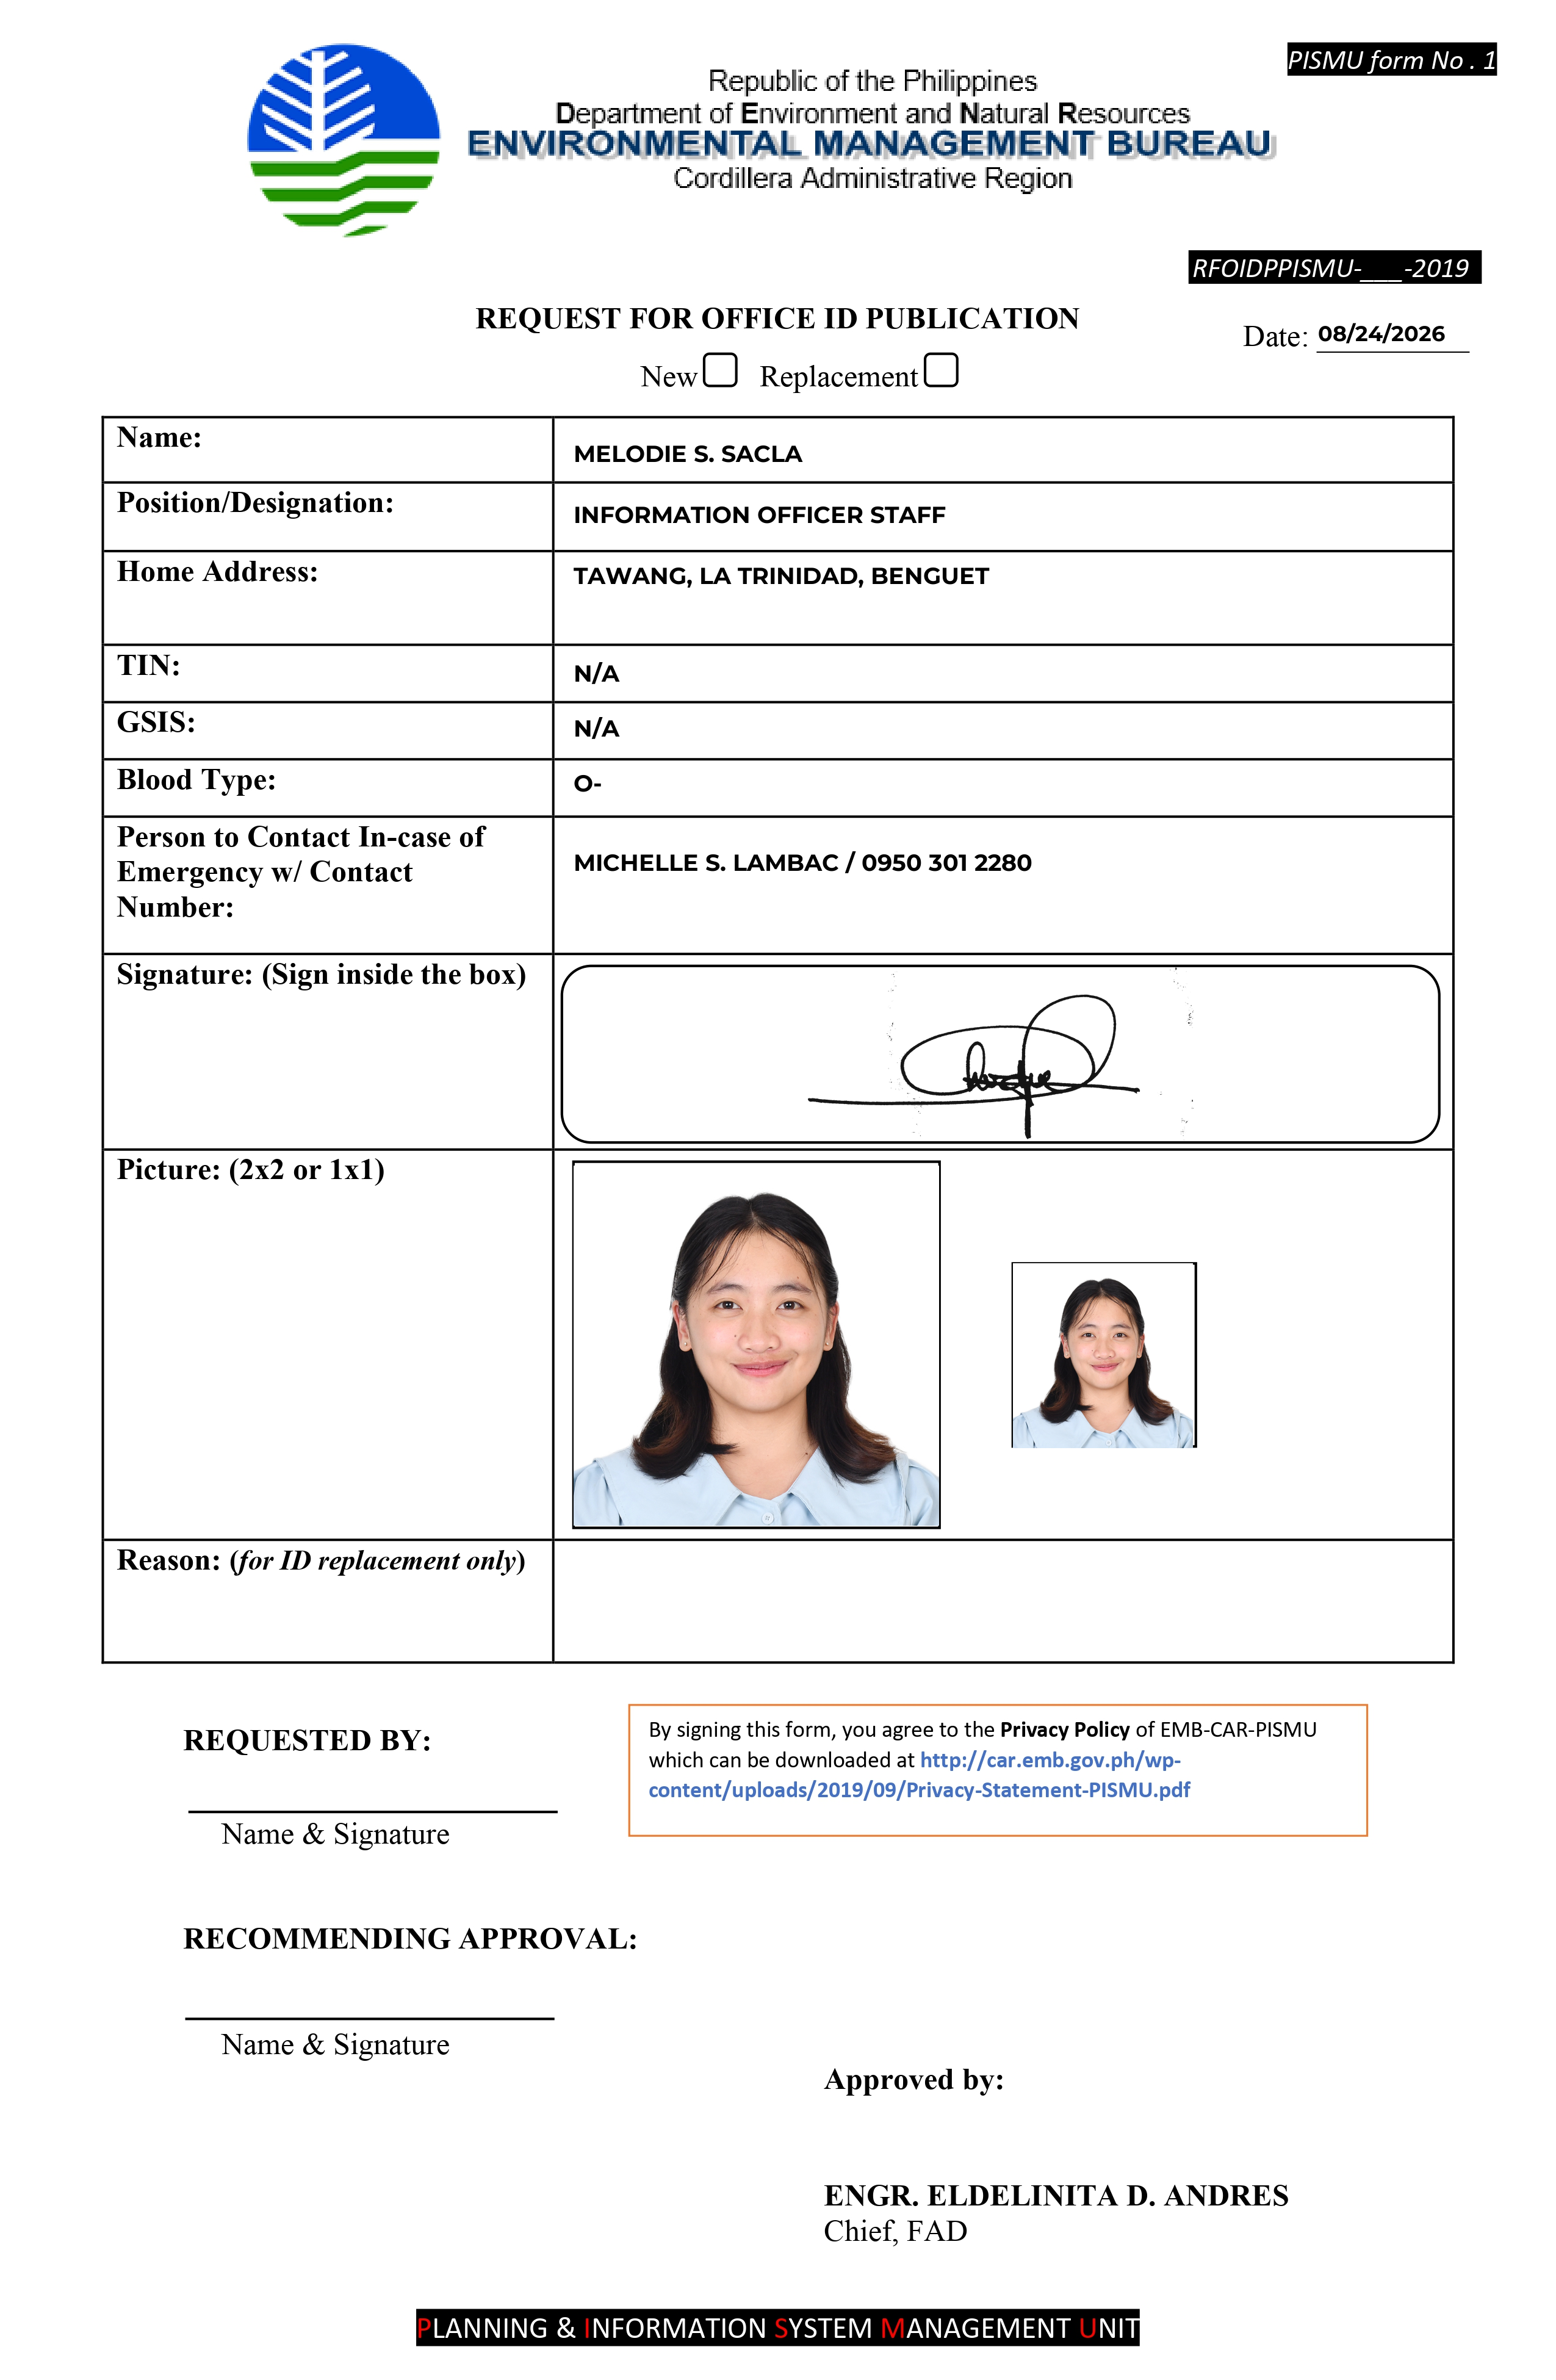

In [23]:
if len(df) == 0:
    print("No responses yet -- nothing to test. Add a form response, then re-run from Stage 2.")
else:
    test_row = df.iloc[0]
    test_id = test_row["id_number"]

    cached = all_results.get(test_id)
    test_photo = cached["photo"] if cached else None
    test_signature = cached["signature"] if cached else None

    if test_photo is None and (PHOTOS_DIR / f"{test_id}.png").exists():
        test_photo = Image.open(PHOTOS_DIR / f"{test_id}.png")
    if test_signature is None and (SIGNATURES_DIR / f"{test_id}.png").exists():
        test_signature = Image.open(SIGNATURES_DIR / f"{test_id}.png")

    form = build_request_form(test_row, test_photo, test_signature)
    display(form)

    

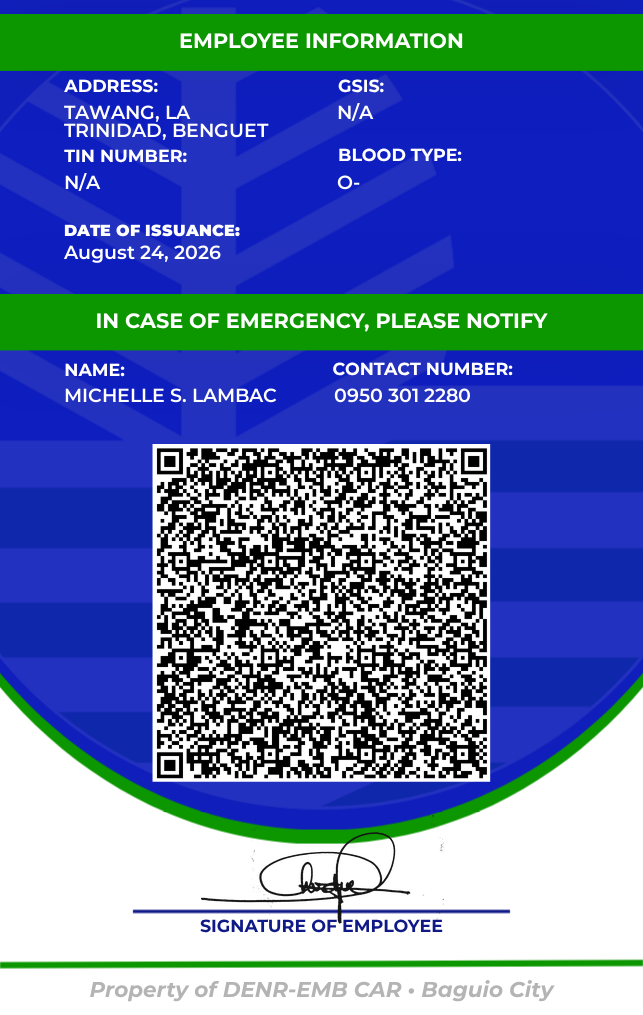

In [24]:
if len(df) > 0:
    back_card = build_back_card(test_row, test_signature)
    display(back_card)

## Stage 5: Generate every card

Skips placeholder-ID rows. Saves into `output/cards/printables/`, with every filename in this run sharing one timestamp so you know exactly when a batch was generated and which files belong together.

In [25]:
def timestamp_str():
    return datetime.now().strftime("%Y%m%d_%H%M%S")   # e.g. 20260824_143205

In [26]:
PRINTED_LOG_FILE = DATA_DIR / "printed_ids.json"

FORCE_REPRINT_ALL = False

FORCE_REPRINT_IDS = set()

if PRINTED_LOG_FILE.exists():
    with open(PRINTED_LOG_FILE) as f:
        printed_ids = set(json.load(f))
else: 
    printed_ids = set()

print(f"{len(printed_ids)} ID(s) already printed in the previous runs")

0 ID(s) already printed in the previous runs


In [27]:
run_timestamp = timestamp_str()
generated_count, skipped_count, skipped_already_printed = 0, 0, 0
newly_printed = set()

for _, row in df.iterrows():
    id_num = row["id_number"]

    if row.get("id_missing", False):
        print(f"Skipping {row['full_name']} -- placeholder ID, needs review")
        skipped_count += 1
        continue
    
    already_printed = id_num in printed_ids
    force_this_one = FORCE_REPRINT_ALL or id_num in FORCE_REPRINT_IDS
    if already_printed and not force_this_one:
        skipped_already_printed += 1
        continue
    
    result = all_results.get(id_num, {})
    photo = result.get("photo")
    signature = result.get("signature")

    if photo is None and (PHOTOS_DIR / f"{id_num}.png").exists():
        photo = Image.open(PHOTOS_DIR / f"{id_num}.png")
    if signature is None and (SIGNATURES_DIR / f"{id_num}.png").exists():
        signature = Image.open(SIGNATURES_DIR / f"{id_num}.png")

    front = build_front_card(row, photo)
    back = build_back_card(row, signature)
    request_form = build_request_form(row, photo, signature)

    safe_id = str(id_num).replace("/", "-")
    front.save(OUTPUT_CARDS_DIR / f"{safe_id}_front_{run_timestamp}.png", dpi=(300, 300))
    back.save(OUTPUT_CARDS_DIR / f"{safe_id}_back_{run_timestamp}.png", dpi=(300, 300))
    request_form.save(OUTPUT_FORMS_DIR / f"{safe_id}_request_form_{run_timestamp}.png", dpi=(300, 300))
    generated_count += 1
    newly_printed.add(id_num)

printed_ids.update(newly_printed)
with open(PRINTED_LOG_FILE, "w") as f:
    json.dump(sorted(printed_ids), f)

print(f"\nGenerated {generated_count} new card(s) into {OUTPUT_CARDS_DIR}")
print(f"Skipped {skipped_count} placeholder-ID row(s)")
print(f"Skipped {skipped_already_printed} already-printed row(s)")


Generated 2 new card(s) into c:\Users\USER\Documents\System Project\id-card-generator\output\cards
Skipped 0 placeholder-ID row(s)
Skipped 0 already-printed row(s)


## Stage 6: Export to a print-ready PDF

Scoped to only this run's files (matched by `run_timestamp`), so it doesn't accidentally pull in every card ever generated across past sessions.

In [28]:
SHARED_PRINT_DIR = Path(r"C:\ID_Card_Printouts")
SHARED_PRINT_DIR.mkdir(parents=True, exist_ok=True)

card_files = []
for _, row in df.iterrows():
    id_num = row["id_number"]
    if row.get("id_missing", False):
        continue
    safe_id = str(id_num).replace("/", "-").upper()
    front_path = OUTPUT_CARDS_DIR / f"{safe_id}_front_{run_timestamp}.png"
    back_path = OUTPUT_CARDS_DIR / f"{safe_id}_back_{run_timestamp}.png"
    if front_path.exists():
        card_files.append(front_path)
    if back_path.exists():
        card_files.append(back_path)

if not card_files:
    print("No cards found for this run -- run Stage 5 first.")
else:
    pdf_bytes = img2pdf.convert([str(p) for p in card_files])

    # Archived, timestamped copy -- permanent record of every batch ever printed
    archive_path = OUTPUT_PRINTABLES_DIR / f"id_cards_print_ready_{run_timestamp}.pdf"
    with open(archive_path, "wb") as f:
        f.write(pdf_bytes)

    # Timestamped copy in the shared folder too, for audit purposes
    shared_path = SHARED_PRINT_DIR / f"id_cards_print_ready_{run_timestamp}.pdf"
    with open(shared_path, "wb") as f:
        f.write(pdf_bytes)

    # Fixed-name copy -- always the most recent batch, so the printer PC
    # operator never needs to know or guess the timestamp
    latest_path = SHARED_PRINT_DIR / "LATEST_print_ready.pdf"
    with open(latest_path, "wb") as f:
        f.write(pdf_bytes)

    print(f"Saved: {archive_path} ({len(card_files)} pages)")
    print(f"Also copied to shared folder: {shared_path}")
    print(f"Updated: {latest_path}")

Saved: c:\Users\USER\Documents\System Project\id-card-generator\output\printables\id_cards_print_ready_20260909_110858.pdf (4 pages)
Also copied to shared folder: C:\ID_Card_Printouts\id_cards_print_ready_20260909_110858.pdf
Updated: C:\ID_Card_Printouts\LATEST_print_ready.pdf


In [29]:
request_form_files = []
for _, row in df.iterrows():
    id_num = row["id_number"]
    if row.get("id_missing", False):
        continue
    safe_id = str(id_num).replace("/", "-").upper()
    form_path = OUTPUT_FORMS_DIR / f"{safe_id}_request_form_{run_timestamp}.png"
    if form_path.exists():
        request_form_files.append(form_path)

if not request_form_files:
    print("No request forms found for this run.")
else:
    form_pdf_bytes = img2pdf.convert([str(p) for p in request_form_files])

    form_archive_path = OUTPUT_FORMS_DIR / f"request_forms_{run_timestamp}.pdf"
    with open(form_archive_path, "wb") as f:
        f.write(form_pdf_bytes)

    form_shared_path = SHARED_PRINT_DIR / f"request_forms_{run_timestamp}.pdf"
    with open(form_shared_path, "wb") as f:
        f.write(form_pdf_bytes)

    latest_form_path = SHARED_PRINT_DIR / "LATEST_request_forms.pdf"
    with open(latest_form_path, "wb") as f:
        f.write(form_pdf_bytes)

    print(f"Saved: {form_archive_path} ({len(request_form_files)} pages)")
    print(f"Also copied to shared folder: {form_shared_path}")
    print(f"Updated: {latest_form_path}")

Saved: c:\Users\USER\Documents\System Project\id-card-generator\output\forms\request_forms_20260909_110858.pdf (2 pages)
Also copied to shared folder: C:\ID_Card_Printouts\request_forms_20260909_110858.pdf
Updated: C:\ID_Card_Printouts\LATEST_request_forms.pdf
